#  Custom CNN — Warping Defect Detection

This notebook trains a **Custom CNN** (trained from scratch) to classify surface images as **Warping** or **No Warping**.

## Architecture

```
Input (224×224×3)
│
Conv2D(32, 3×3)  → BatchNorm → ReLU → MaxPool(2×2)
Conv2D(64, 3×3)  → BatchNorm → ReLU → MaxPool(2×2)
Conv2D(128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
Conv2D(256, 3×3) → BatchNorm → ReLU → MaxPool(2×2)
│
GlobalAveragePooling2D
Dense(256, ReLU)
Dropout(0.3)
Dense(1, Sigmoid)
```

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-05-05 01:12:46.528946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777939966.550036   21998 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777939966.556750   21998 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 01:12:46.580334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Warping/` and `No_Warping/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [2]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

warping_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Warping", "*.jpg")))
no_warping_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Warping", "*.jpg")))

print(f"Warping images    : {len(warping_files)}")
print(f"No_Warping images : {len(no_warping_files)}")

# Label: Warping = 1, No_Warping = 0
all_files  = warping_files + no_warping_files
all_labels = [1] * len(warping_files) + [0] * len(no_warping_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Warping images    : 1707
No_Warping images : 1815

Train : 2817
Val   : 352
Test  : 353


### 1.1 — Build `tf.data` pipelines with augmentation

In [3]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1777939968.890392   21998 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5779 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

2026-05-05 01:13:02.270112: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


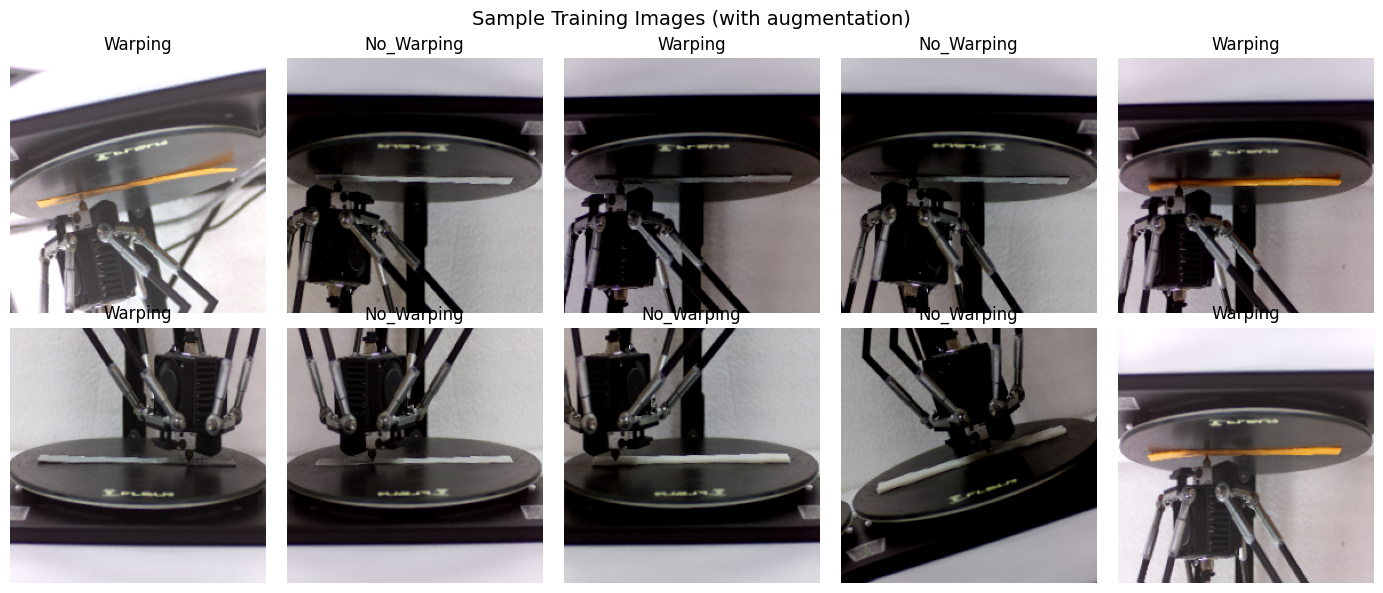

In [4]:
class_names = ["No_Warping", "Warping"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

Custom CNN trained **from scratch** (no pretrained weights).

```
Input (224×224×3)
│
Conv2D(32, 3×3)  → BatchNorm → ReLU → MaxPool(2×2)   # 112×112×32
Conv2D(64, 3×3)  → BatchNorm → ReLU → MaxPool(2×2)   #  56×56×64
Conv2D(128, 3×3) → BatchNorm → ReLU → MaxPool(2×2)   #  28×28×128
Conv2D(256, 3×3) → BatchNorm → ReLU → MaxPool(2×2)   #  14×14×256
│
GlobalAveragePooling2D                                 # 256
Dense(256, ReLU)
Dropout(0.3)
Dense(1, Sigmoid)
```

In [5]:
# ---------- Build Custom CNN from scratch ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

# Block 1 — 224×224×3 → 112×112×32
x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv1")(inputs)
x = layers.BatchNormalization(name="bn1")(x)
x = layers.Activation("relu", name="relu1")(x)
x = layers.MaxPooling2D((2, 2), name="pool1")(x)

# Block 2 — 112×112×32 → 56×56×64
x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv2")(x)
x = layers.BatchNormalization(name="bn2")(x)
x = layers.Activation("relu", name="relu2")(x)
x = layers.MaxPooling2D((2, 2), name="pool2")(x)

# Block 3 — 56×56×64 → 28×28×128
x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False, name="conv3")(x)
x = layers.BatchNormalization(name="bn3")(x)
x = layers.Activation("relu", name="relu3")(x)
x = layers.MaxPooling2D((2, 2), name="pool3")(x)

# Block 4 — 28×28×128 → 14×14×256
x = layers.Conv2D(256, (3, 3), padding="same", use_bias=False, name="conv4")(x)
x = layers.BatchNormalization(name="bn4")(x)
x = layers.Activation("relu", name="relu4")(x)
x = layers.MaxPooling2D((2, 2), name="pool4")(x)

# Classification head
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="CustomCNN_Warping")
model.summary()

Model: "CustomCNN_Warping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,905 (1.74 MB)

 Trainable params: 454,945 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [7]:
EPOCHS = 50
BEST_MODEL_PATH = "best_custom_cnn_warping.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1777939989.642379   22093 service.cc:148] XLA service 0x7921640024a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777939989.643128   22093 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-05 01:13:10.395744: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777939991.860999   22093 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/89 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5503 - loss: 0.7240 

I0000 00:00:1777939995.168460   22093 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.5605 - loss: 0.7009
Epoch 1: val_loss improved from None to 0.69367, saving model to best_custom_cnn_warping.h5


...


Epoch 3: finished saving model to best_custom_cnn_warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 47s 522ms/step - accuracy: 0.6834 - loss: 0.5533 - val_accuracy: 0.5398 - val_loss: 0.6675 - learning_rate: 1.0000e-04
Epoch 4/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.7118 - loss: 0.5363
Epoch 4: val_loss did not improve from 0.66754
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 473ms/step - accuracy: 0.7050 - loss: 0.5376 - val_accuracy: 0.4972 - val_loss: 0.7080 - learning_rate: 1.0000e-04
Epoch 5/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7209 - loss: 0.5226
Epoch 5: val_loss did not improve from 0.66754
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 491ms/step - accuracy: 0.6986 - loss: 0.5362 - val_accuracy: 0.4972 - val_loss: 0.7836 - learning_rate: 1.0000e-04
Epoch 6/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7077 - loss: 0.5212
Epoch 6: val_loss did not improve from 0.66754
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 463ms/step - accuracy: 0.7082 - loss: 0.5186 - val_accuracy: 0.5057 - 


Epoch 7: finished saving model to best_custom_cnn_warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 488ms/step - accuracy: 0.7224 - loss: 0.5065 - val_accuracy: 0.7415 - val_loss: 0.5152 - learning_rate: 1.0000e-04
Epoch 8/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7084 - loss: 0.5232
Epoch 8: val_loss did not improve from 0.51523
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 490ms/step - accuracy: 0.7203 - loss: 0.5105 - val_accuracy: 0.5597 - val_loss: 0.6550 - learning_rate: 1.0000e-04
Epoch 9/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7302 - loss: 0.5064
Epoch 9: val_loss improved from 0.51523 to 0.41669, saving model to best_custom_cnn_warping.h5



Epoch 9: finished saving model to best_custom_cnn_warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 49s 539ms/step - accuracy: 0.7341 - loss: 0.4938 - val_accuracy: 0.8068 - val_loss: 0.4167 - learning_rate: 1.0000e-04
Epoch 10/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7412 - loss: 0.4920
Epoch 10: val_loss did not improve from 0.41669
89/89 ━━━━━━━━━━━━━━━━━━━━ 47s 527ms/step - accuracy: 0.7416 - loss: 0.4971 - val_accuracy: 0.7841 - val_loss: 0.4547 - learning_rate: 1.0000e-04
Epoch 11/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.7545 - loss: 0.4769
Epoch 11: val_loss did not improve from 0.41669
89/89 ━━━━━━━━━━━━━━━━━━━━ 47s 524ms/step - accuracy: 0.7568 - loss: 0.4711 - val_accuracy: 0.5085 - val_loss: 1.5970 - learning_rate: 1.0000e-04
Epoch 12/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7497 - loss: 0.4833
Epoch 12: val_loss did not improve from 0.41669
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 468ms/step - accuracy: 0.7526 - loss: 0.4808 - val_accuracy: 0.6


Epoch 16: finished saving model to best_custom_cnn_warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 42s 473ms/step - accuracy: 0.7881 - loss: 0.4345 - val_accuracy: 0.8494 - val_loss: 0.3620 - learning_rate: 5.0000e-05
Epoch 17/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7840 - loss: 0.4245
Epoch 17: val_loss did not improve from 0.36196
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 481ms/step - accuracy: 0.7898 - loss: 0.4202 - val_accuracy: 0.5199 - val_loss: 1.0300 - learning_rate: 5.0000e-05
Epoch 18/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8010 - loss: 0.4094
Epoch 18: val_loss did not improve from 0.36196
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 487ms/step - accuracy: 0.8030 - loss: 0.4063 - val_accuracy: 0.5199 - val_loss: 0.9858 - learning_rate: 5.0000e-05
Epoch 19/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7913 - loss: 0.4407
Epoch 19: val_loss did not improve from 0.36196
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 458ms/step - accuracy: 0.8069 - loss: 0.4181 - val_accuracy: 0.


Epoch 20: finished saving model to best_custom_cnn_warping.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 487ms/step - accuracy: 0.8222 - loss: 0.3951 - val_accuracy: 0.8920 - val_loss: 0.2813 - learning_rate: 5.0000e-05
Epoch 21/50
85/89 ━━━━━━━━━━━━━━━━━━━━ 1s 428ms/step - accuracy: 0.8329 - loss: 0.3726
Epoch 21: val_loss did not improve from 0.28134
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.8335 - loss: 0.3779 - val_accuracy: 0.9006 - val_loss: 0.3071 - learning_rate: 5.0000e-05
Epoch 22/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8408 - loss: 0.3663
Epoch 22: val_loss did not improve from 0.28134
89/89 ━━━━━━━━━━━━━━━━━━━━ 44s 491ms/step - accuracy: 0.8346 - loss: 0.3713 - val_accuracy: 0.5682 - val_loss: 0.7028 - learning_rate: 5.0000e-05
Epoch 23/50
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8212 - loss: 0.3838
Epoch 23: val_loss did not improve from 0.28134
89/89 ━━━━━━━━━━━━━━━━━━━━ 41s 460ms/step - accuracy: 0.8307 - loss: 0.3759 - val_accuracy: 0.

---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [8]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step
Test samples : 353


### 5.2 — Classification metrics

In [9]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.8470
  Precision : 0.8471
  Recall    : 0.8372
  F1-Score  : 0.8421

              precision    recall  f1-score   support

  No_Warping       0.85      0.86      0.85       181
     Warping       0.85      0.84      0.84       172

    accuracy                           0.85       353
   macro avg       0.85      0.85      0.85       353
weighted avg       0.85      0.85      0.85       353



### 5.3 — Confusion Matrix

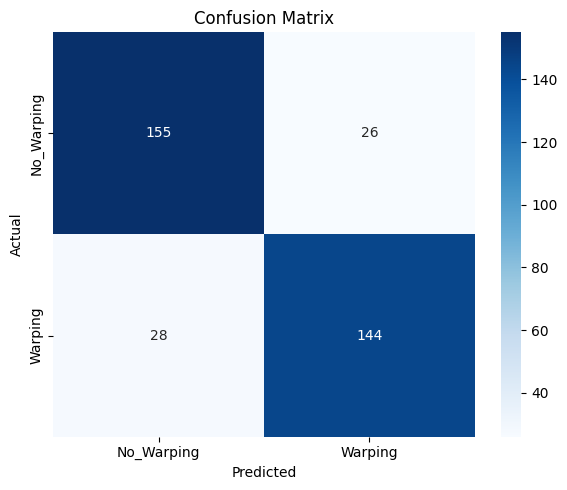

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

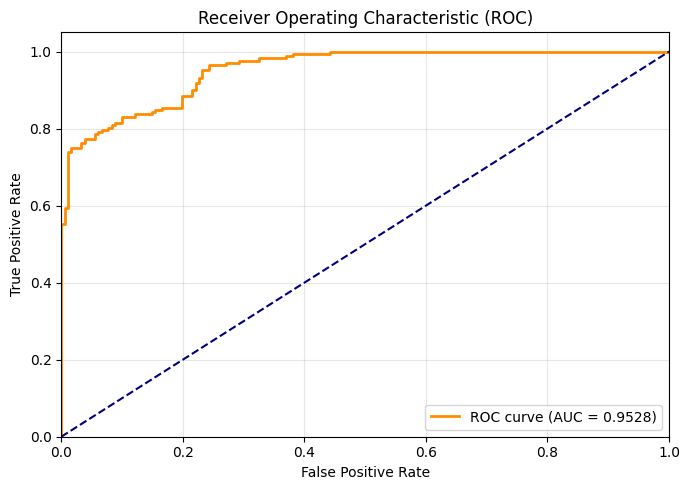

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

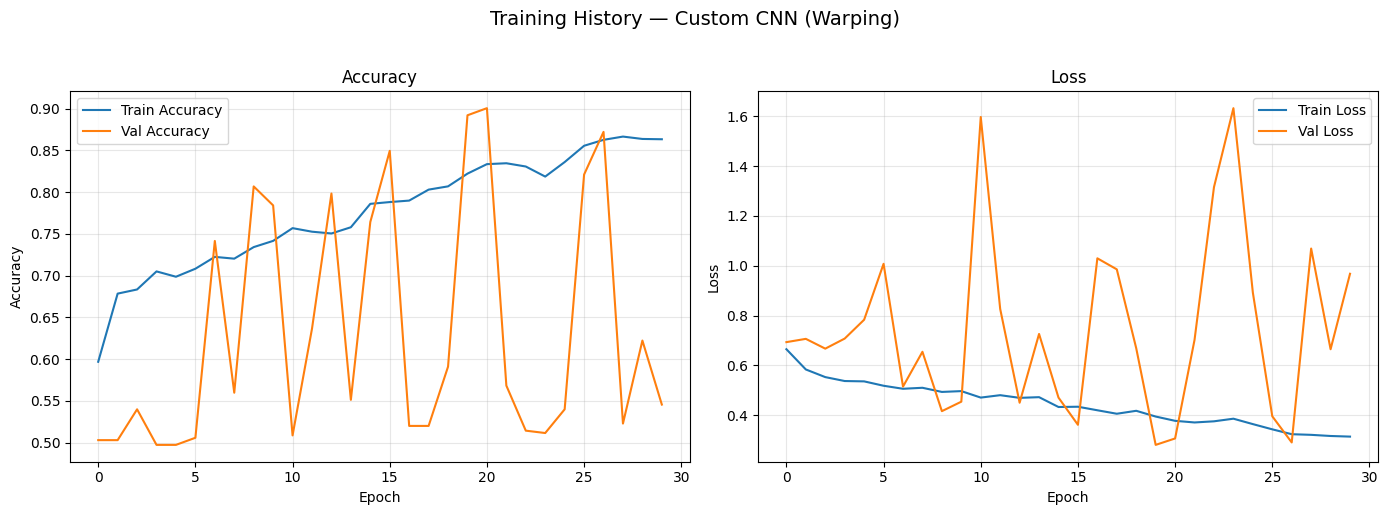

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History — Custom CNN (Warping)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras HDF5 format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [13]:
# 1) Save as .h5
H5_PATH = "custom_cnn_Warping_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "custom_cnn_Warping_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → custom_cnn_Warping_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=custom_cnn_Warping_savedmodel.

---
### ✅ Done!

The trained **Custom CNN** model for **Warping vs No_Warping** detection is now saved and ready for deployment or TFLite conversion.